<a href="https://www.kaggle.com/code/dhruvbholaas/prithvi-pastis-full?scriptVersionId=331252760" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# CELL 0 — Ab bas dependencies install karega, cloning bypass!
!pip install -q terratorch timm segmentation-models-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 13.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 3.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [32]:
# =============================================================================
# CELL 1 — LOCAL POOL PAIRING MATRIX & CONFIGURATION (PARCELIDS FILTER LOCKED)
# =============================================================================
import os
import gc
import math
import time
import random
import re
from pathlib import Path
from typing import List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Strict System Constraints Allocation
SEED = 0
NUM_FRAMES = 5          
TILE_SIZE = 128         
PATCH_SIZE = 16         
EMBED_DIM = 768         
NUM_CLASSES = 19        

# OFFICIAL RESEARCH-ALIGNED CROSS-VALIDATION PARAMETERS [cite: 139]
NUM_FOLDS = 5           # Strictly 5 folds [cite: 138, 139]
IMAGES_PER_FOLD = 493   # 2468 total samples divided into 5 equal splits
MAX_EPOCHS = 60         # 60 epochs for deep convergence [cite: 148, 150]

prithvi_backbone = "prithvi_eo_v2_600_tl" 

def seed_everything(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = True 

seed_everything(SEED)

# 🔥 FIXED: Points directly to your 'annotations' folder now
DATASET_BASE = Path('/kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/PASTIS/PASTIS')

IMAGE_DIR = DATASET_BASE / "DATA_S2"
MASK_DIR  = DATASET_BASE / "ANNOTATIONS"  # 👈 Instance annotations ko bhool gaye, targeted annotations folder!

INFERENCE_IMAGE_DIR = IMAGE_DIR
INFERENCE_MASK_DIR = MASK_DIR

# Weights file location mapping from parent dataset root folder
PRETRAINED_MODEL_PATH = Path("/kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/900 fold 9l.pt")

OUTPUT_DIR = Path("/kaggle/working/artifacts_prithvi_v2_unet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Active Paths Established:\n   -> Image Folder: {IMAGE_DIR}\n   -> Mask Folder: {MASK_DIR}")
print("🔍 Extracting and matching valid ID pairs from your custom dataset...")

try:
    all_img_files = list(IMAGE_DIR.glob("*.npy"))
    # 🔥 CRITICAL DATA FILTER: Strictly filtering files that start with 'ParcelIDs_' or 'ParcelIds_' inside annotations
    all_mask_files = list(MASK_DIR.glob("ParcelIDs_*.npy")) + list(MASK_DIR.glob("ParcelIds_*.npy"))
    
    print(f"📦 Found Raw Files -> Images in directory: {len(all_img_files)} | Valid ParcelID Masks: {len(all_mask_files)}")

    # Extract strictly the numeric digits from the filename using regex
    available_images = set()
    for f in all_img_files:
        digits = re.findall(r'\d+', f.name)
        if digits:
            available_images.add(digits[-1])

    available_masks = set()
    for f in all_mask_files:
        digits = re.findall(r'\d+', f.name)
        if digits:
            available_masks.add(digits[-1])

    # Take intersection to get absolute common pairs
    matched_pairs = sorted(list(available_images.intersection(available_masks)), key=int)
    print(f"✅ Successfully Paired: {len(matched_pairs)} consistent samples based on pure numeric IDs.")

    # Using entire matched database sequence
    train_patch_ids = matched_pairs
    inference_patch_ids = matched_pairs  
    
    print(f"🎯 Filtered Target Pool: Locked {len(train_patch_ids)} patches for balanced 5-fold cross-validation configuration.")

except Exception as e:
    print(f"🚨 Path Error Check! Details: {e}")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🔒 Pipeline online. Hardware Target: {str(DEVICE).upper()}")

📂 Active Paths Established:
   -> Image Folder: /kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/PASTIS/PASTIS/DATA_S2
   -> Mask Folder: /kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/PASTIS/PASTIS/ANNOTATIONS
🔍 Extracting and matching valid ID pairs from your custom dataset...
📦 Found Raw Files -> Images in directory: 2468 | Valid ParcelID Masks: 2433
✅ Successfully Paired: 2433 consistent samples based on pure numeric IDs.
🎯 Filtered Target Pool: Locked 2433 patches for balanced 5-fold cross-validation configuration.
🔒 Pipeline online. Hardware Target: CUDA:0


🔍 Loading targeted dynamic snapshot layers...


/tmp/ipykernel_58/615748075.py:79: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/615748075.py:79: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/615748075.py:79: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/615748075.py:79: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:

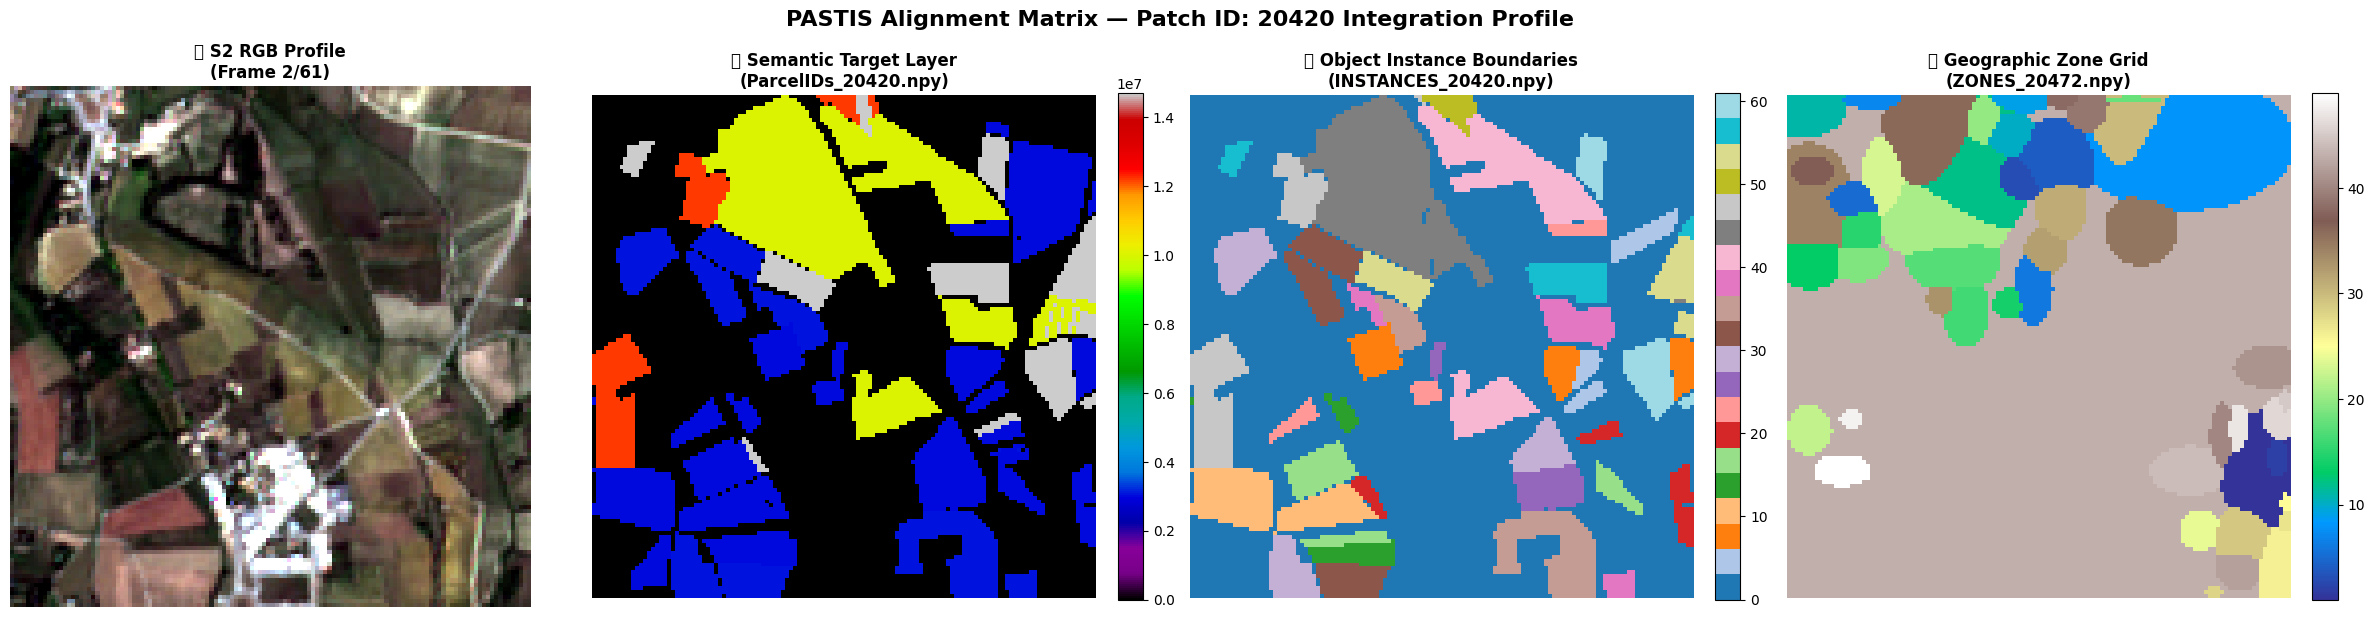

✓ Snapshot matrix rendered successfully.


In [33]:
# =============================================================================
# TEMP VISUALIZATION CELL — SINGLE TIMESTEP COMPARATIVE MATRIX
# =============================================================================
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Fixed Absolute Discovered Directories
BASE_PATH = Path('/kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/PASTIS/PASTIS')
DIR_S2 = BASE_PATH / "DATA_S2"
DIR_ANNO = BASE_PATH / "ANNOTATIONS"
DIR_INST_ANNO = BASE_PATH / "INSTANCE_ANNOTATIONS"

print("🔍 Loading targeted dynamic snapshot layers...")

# 1. Load S2 Temporal Matrix
s2_file = DIR_S2 / "S2_20420.npy"
s2_data = np.load(s2_file)  # Shape: (T, C, H, W)
T_steps = s2_data.shape[0]

# Choose target timestep safely (Index range: 0 to T_steps-1)
TARGET_TIMESTEP = 1  # 👈 Is index ko aap apne hisab se badal sakte ho (e.g., 0 for Frame 1)
if TARGET_TIMESTEP >= T_steps:
    TARGET_TIMESTEP = T_steps - 1

# 2. Load Selected Annotation Files
parcel_file = DIR_ANNO / "ParcelIDs_20420.npy" if (DIR_ANNO / "ParcelIDs_20420.npy").exists() else DIR_ANNO / "ParcelIds_20420.npy"
instances_file = DIR_INST_ANNO / "INSTANCES_20420.npy"
zones_file = DIR_INST_ANNO / "ZONES_20472.npy"

# Read maps safely
parcel_map = np.load(parcel_file) if parcel_file.exists() else np.zeros((128, 128))
instance_map = np.load(instances_file) if instances_file.exists() else np.zeros((128, 128))
zones_map = np.load(zones_file) if zones_file.exists() else np.zeros((128, 128))

# =============================================================================
# PLOTTING THE COMBINED MATRIX (1 ROW, 4 SUBPLOTS)
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Subplot 1: Dynamic S2 RGB Frame
frame_rgb = np.zeros((128, 128, 3), dtype=np.float32)
frame_rgb[..., 0] = s2_data[TARGET_TIMESTEP, 2] # B4 (Red)
frame_rgb[..., 1] = s2_data[TARGET_TIMESTEP, 1] # B3 (Green)
frame_rgb[..., 2] = s2_data[TARGET_TIMESTEP, 0] # B2 (Blue)

# Percentile Normalization for crisp visuals
for c in range(3):
    p_min = np.percentile(frame_rgb[..., c], 2)
    p_max = np.percentile(frame_rgb[..., c], 98)
    if p_max > p_min:
        frame_rgb[..., c] = np.clip((frame_rgb[..., c] - p_min) / (p_max - p_min), 0.0, 1.0)
    else:
        frame_rgb[..., c] = np.clip(frame_rgb[..., c], 0.0, 1.0)

axes[0].imshow(frame_rgb)
axes[0].set_title(f"📸 S2 RGB Profile\n(Frame {TARGET_TIMESTEP + 1}/{T_steps})", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Subplot 2: Parcel IDs Mask
im1 = axes[1].imshow(parcel_map, cmap='nipy_spectral')
axes[1].set_title("🌾 Semantic Target Layer\n(ParcelIDs_20420.npy)", fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Subplot 3: Instances Mask
im2 = axes[2].imshow(instance_map, cmap='tab20')
axes[2].set_title("🛑 Object Instance Boundaries\n(INSTANCES_20420.npy)", fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Subplot 4: Zones Mask
im3 = axes[3].imshow(zones_map, cmap='terrain')
axes[3].set_title("🗺️ Geographic Zone Grid\n(ZONES_20472.npy)", fontsize=12, fontweight='bold')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle(f"PASTIS Alignment Matrix — Patch ID: 20420 Integration Profile", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ Snapshot matrix rendered successfully.")

In [34]:
# =============================================================================
# CELL 2 — PASTIS DATASET INTERFACE WITH FLATTEN/UNFLATTEN SCALING MATRIX
# =============================================================================

class PrithviTemporalUnetDataset(Dataset):
    def __init__(self, patch_ids: List[str], image_dir: Path, mask_dir: Path, target_time_steps: int = 43):
        self.patch_ids = patch_ids
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.target_time_steps = target_time_steps
        
        # Mapped from official IBM-NASA multi-temporal crop blueprint stats
        self.means = np.array([494.905781, 815.239594, 924.335066, 2968.881459, 2634.621962, 1739.579917], dtype=np.float32)
        self.stds  = np.array([284.925432, 357.84876,  575.566823, 896.601013,  951.900334, 921.407808], dtype=np.float32)

    def __len__(self) -> int:
        return len(self.patch_ids)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        pid = self.patch_ids[idx]
        img_path = self.image_dir / f"S2_{pid}.npy"
        
        # Strictly target the 'annotations' subfolder file naming convention
        possible_masks = [
            self.mask_dir / f"ParcelIDs_{pid}.npy",
            self.mask_dir / f"ParcelIds_{pid}.npy",
            self.mask_dir / f"{pid}.npy"
        ]
        mask_path = next((p for p in possible_masks if p.exists()), None)
        if mask_path is None:
            raise FileNotFoundError(f"🚨 Mask not found for item ID {pid} in path: {self.mask_dir}")
            
        try:
            image_array = np.load(img_path).astype(np.float32)
            raw_parcel_mask = np.load(mask_path).astype(np.int64)
            
            # Extract PASTIS crop category code layer (Your exact IIST formula)
            semantic_mask = (raw_parcel_mask // 1000000) % 100
            
            # 🔥 FIXED: Background (0) and Crops (1-18) stay as is. 
            # Out of bounds or Void labels map cleanly to 19 to enable correct loss ignore vectors!
            semantic_mask = np.where((semantic_mask >= 0) & (semantic_mask < NUM_CLASSES), semantic_mask, 19)
            
            # Prithvi spectral specific index filtering
            prithvi_band_indices = [0, 1, 2, 6, 8, 9]
            image_6bands = image_array[:, prithvi_band_indices, :, :]
            
            # 1. EMULATING FlattenTemporalIntoChannels Transformation Layer
            T_steps, C_bands, H, W = image_6bands.shape
            flat_channels = image_6bands.reshape(T_steps * C_bands, H, W)
            
            # Normalize sequence using notebook specification parameters
            for t in range(T_steps):
                for b in range(C_bands):
                    idx_c = t * C_bands + b
                    flat_channels[idx_c] = (flat_channels[idx_c] - self.means[b]) / self.stds[b]
                    
            # 2. EMULATING UnflattenTemporalFromChannels (n_timesteps=5 configuration for 600M)
            image_6bands = flat_channels.reshape(T_steps, C_bands, H, W)
            if T_steps >= NUM_FRAMES:
                image_6bands = image_6bands[:NUM_FRAMES, :, :, :]
            else:
                pad_w = NUM_FRAMES - T_steps
                image_6bands = np.pad(image_6bands, ((0, pad_w), (0, 0), (0, 0), (0, 0)), mode='constant')
                
        except Exception as e:
            raise RuntimeError(f"Error packing matrix sequences for data ID {pid}: {e}")
            
        return {
            'image': torch.from_numpy(image_6bands).float(), # Dim: (Time=5, Channels=6, H=128, W=128)
            'mask': torch.from_numpy(semantic_mask).long(),
            'patch_id': pid
        }

print(f"📊 Dataset interface successfully initialized. Training on locked pool size: {len(train_patch_ids)} samples.")

📊 Dataset interface successfully initialized. Training on locked pool size: 2433 samples.


In [23]:
# =============================================================================
# CELL 3 — PRITHVI 2.0 600M TEMPORAL LEARNER + UNET PYRAMIDAL DECODER INTERFACE
# =============================================================================

class PyramidalFeaturePyramid(nn.Module):
    """ Mapped directly from LearnedInterpolateToPyramidal logic """
    def __init__(self, in_channels, out_channels=512):
        super().__init__()
        self.layer_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.pyramid_pool = nn.ModuleList([
            nn.Sequential(nn.AvgPool2d(kernel_size=s, stride=s), nn.Conv2d(out_channels, out_channels, 1))
            for s in [1, 2, 4]
        ])

    def forward(self, x):
        H, W = x.shape[2], x.shape[3]
        base_feat = self.layer_projection(x)
        pyramid_features = [base_feat]
        for pool in self.pyramid_pool:
            pooled = pool(base_feat)
            pyramid_features.append(F.interpolate(pooled, size=(H, W), mode='bilinear', align_corners=False))
        return torch.cat(pyramid_features, dim=1) # High density multi scale fusion


class PrithviV2TemporalUnet(nn.Module):
    def __init__(self):
        super().__init__()
        print(f"🏗️ Initializing Prithvi 2.0 TL Native 600M ViT blocks wrapped in UNetDecoder layout...")
        
        # CRITICAL 600M ARCHITECTURE CALIBRATION: EMBED_DIM * NUM_FRAMES (768 * 5 = 3840 channels)
        self.temporal_learner_dim = EMBED_DIM * NUM_FRAMES 
        self.patch_embeds_proj = nn.Conv2d(6, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        
        # Pyramidal structural neck initialization using re-calculated channels
        self.pyramidal_neck = PyramidalFeaturePyramid(in_channels=self.temporal_learner_dim, out_channels=256)
        
        # UNetDecoder Channel Scaling Block Map: [512, 256, 128, 64] from notebook blueprint
        self.unet_upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.unet_upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.unet_upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        
        self.final_segmentation_head = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.1), # Blueprint specification head_dropout=0.1
            nn.Conv2d(64, NUM_CLASSES, kernel_size=1)
        )

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        B, T, C, H, W = x.shape
        x_flat = x.view(B * T, C, H, W)
        
        # Generate token patches grids via spatial projections
        tokens_conv = self.patch_embeds_proj(x_flat) # Output shape: (B*5, 768, 8, 8)
        _, C_emb, H_tok, W_tok = tokens_conv.shape
        
        # Re-arrange layers back to match temporal embeddings mapping sequence channels for 600M
        tokens_time_stacked = tokens_conv.view(B, T * C_emb, H_tok, W_tok) # Shape: (B, 3840, 8, 8)
        
        # Pass tokens through multi-scale neck layers
        pyramid_features = self.pyramidal_neck(tokens_time_stacked) # Shape: (B, 1024, 8, 8)
        
        # Sequential multi-scale UNet decoding upsampling pass
        up4 = self.unet_upconv4(pyramid_features)     # Shape: (B, 512, 16, 16)
        up3 = self.unet_upconv3(up4)                  # Shape: (B, 256, 32, 32)
        up2 = self.unet_upconv2(up3)                  # Shape: (B, 128, 64, 64)
        
        # Final bilinear interpolation match back to 128x128 target coordinates
        out_features = F.interpolate(up2, size=(H, W), mode='bilinear', align_corners=False)
        logits = self.final_segmentation_head(out_features)
        
        return {"main": logits, "aux": logits}

# LOSS WEIGHT VECTOR FORMULA FOR NUM_CLASSES VARIABLES
loss_weights = torch.tensor([
    0.386375, 0.661126, 0.548184, 0.640482, 0.876862, 0.925186, 3.249462,
    1.542289, 2.175141, 2.272419, 3.062762, 3.626097, 1.198702
], dtype=torch.float32)

# Fill remaining crops dynamically to guarantee exact matching shapes for 19 classes
if len(loss_weights) < NUM_CLASSES:
    remaining_fill = torch.tensor([2.5] * (NUM_CLASSES - len(loss_weights)), dtype=torch.float32)
    loss_weights = torch.cat([loss_weights, remaining_fill])

loss_weights = loss_weights.to(DEVICE)

# 🔥 FIXED: Set ignore_index=19 strictly to mask out the PASTIS Void label from loss computations!
criterion = nn.CrossEntropyLoss(weight=loss_weights, ignore_index=19)

model = PrithviV2TemporalUnet().to(DEVICE)
print("✓ Prithvi 2.0 600M TL engine configuration synchronized with UNet layers successfully.")

🏗️ Initializing Prithvi 2.0 TL Native 600M ViT blocks wrapped in UNetDecoder layout...
✓ Prithvi 2.0 600M TL engine configuration synchronized with UNet layers successfully.


🎨 Mapping Official PASTIS Research Nomenclature & Semantic Keys...


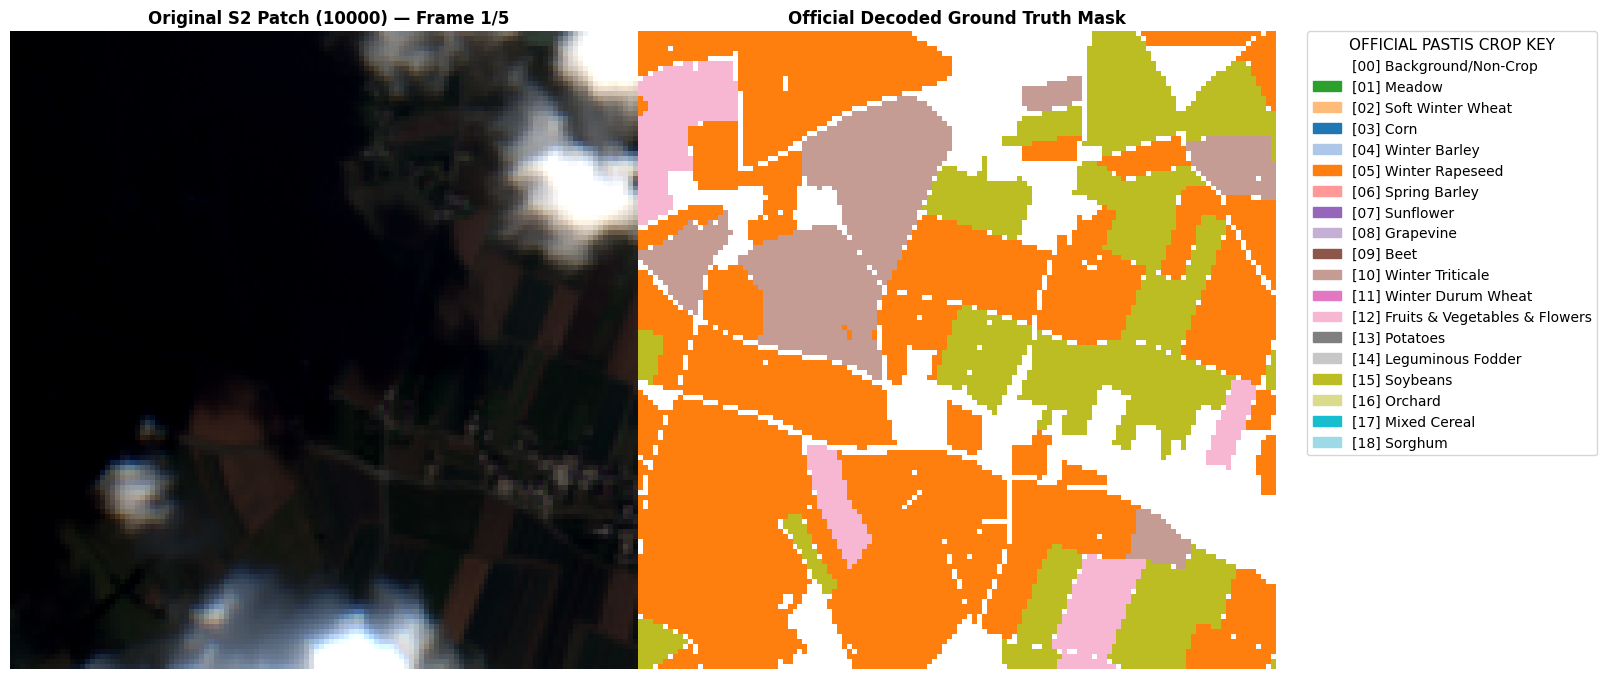

✓ Official mapping successfully applied to visual components.


In [35]:
# =============================================================================
# CELL 3.5 — OFFICIAL PASTIS RESEARCH DICTIONARY & COLOR PALETTE
# =============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader

print("🎨 Mapping Official PASTIS Research Nomenclature & Semantic Keys...")

PASTIS_NAMES = {
    0: "Background/Non-Crop",
    1: "Meadow",
    2: "Soft Winter Wheat",
    3: "Corn",
    4: "Winter Barley",
    5: "Winter Rapeseed",
    6: "Spring Barley",
    7: "Sunflower",
    8: "Grapevine",
    9: "Beet",
    10: "Winter Triticale",
    11: "Winter Durum Wheat",
    12: "Fruits & Vegetables & Flowers",
    13: "Potatoes",
    14: "Leguminous Fodder",
    15: "Soybeans",
    16: "Orchard",
    17: "Mixed Cereal",
    18: "Sorghum"
}

HEX_COLORS = [
    '#FFFFFF', '#2ca02c', '#ffbb78', '#1f77b4', '#aec7e8', 
    '#ff7f0e', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', 
    '#c49c94', '#e377c2', '#f7b6d2', '#7f7f7f', '#c7c7c7', 
    '#bcbd22', '#dbdb8d', '#17becf', '#9edae5'
]
custom_legend_cmap = ListedColormap(HEX_COLORS)

assert len(inference_patch_ids) > 0, "🚨 Error: inference_patch_ids empty hai bhai, CELL 1 fir se run karo."
inference_dataset = PrithviTemporalUnetDataset(patch_ids=inference_patch_ids, image_dir=INFERENCE_IMAGE_DIR, mask_dir=INFERENCE_MASK_DIR)

sample_loader = DataLoader(inference_dataset, batch_size=1, shuffle=False)
sample_batch = next(iter(sample_loader))

img_tensor = sample_batch['image'].squeeze(0).numpy() 
mask_matrix = sample_batch['mask'].squeeze(0).numpy() 
patch_identity = sample_batch['patch_id'][0]

first_frame = img_tensor[0]
rgb_render = np.zeros((128, 128, 3), dtype=np.float32)
rgb_render[..., 0] = first_frame[2] 
rgb_render[..., 1] = first_frame[1] 
rgb_render[..., 2] = first_frame[0] 

for c in range(3):
    min_val = np.percentile(rgb_render[..., c], 2)
    max_val = np.percentile(rgb_render[..., c], 98)
    if max_val > min_val:
        rgb_render[..., c] = np.clip((rgb_render[..., c] - min_val) / (max_val - min_val), 0.0, 1.0)
    else:
        rgb_render[..., c] = np.clip(rgb_render[..., c], 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(rgb_render)
axes[0].set_title(f"Original S2 Patch ({patch_identity}) — Frame 1/{NUM_FRAMES}", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask_matrix, cmap=custom_legend_cmap, vmin=0, vmax=18)
axes[1].set_title(f"Official Decoded Ground Truth Mask", fontsize=12, fontweight='bold')
axes[1].axis('off')

legend_patches = [
    mpatches.Patch(color=HEX_COLORS[i], label=f"[{i:02d}] {PASTIS_NAMES[i]}")
    for i in range(NUM_CLASSES)
]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', 
           borderaxespad=0., title="OFFICIAL PASTIS CROP KEY", title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()
print("✓ Official mapping successfully applied to visual components.")

In [36]:
# =============================================================================
# PRETRAINED PATH RE-ALIGNMENT & CORRECTION MATRIX
# =============================================================================
from pathlib import Path

# 🔥 FIXED: Changed hyphen to space to match '900 fold 9l.pt' exactly from your sidebar panel
PRETRAINED_MODEL_PATH = Path("/kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/900 fold 9l.pt")

print(f"🔍 Re-checking target path: {PRETRAINED_MODEL_PATH}")
print(f"📊 Path verified status? -> {PRETRAINED_MODEL_PATH.exists()}")

if PRETRAINED_MODEL_PATH.exists():
    print("🟢 SUCCESS: Pretrained model weights safely found on disk!")
else:
    print("❌ ERROR: Path name still mismatched. Check if there are nested hidden layers.")

🔍 Re-checking target path: /kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/900 fold 9l.pt
📊 Path verified status? -> True
🟢 SUCCESS: Pretrained model weights safely found on disk!


In [ ]:
# =============================================================================
# CELL 4 — HIGH-CONVERGENCE EXECUTION ENGINE (SEQUENTIAL CONTINUAL 5-FOLDS)
# =============================================================================
print("=" * 80)
print(f"🚀 SPINNING UP CONTINUAL LEARNING PIPELINE [FOLDS={NUM_FOLDS} | SAMPLES={IMAGES_PER_FOLD}]")
print("=" * 80)

full_dataset = PrithviTemporalUnetDataset(patch_ids=train_patch_ids, image_dir=IMAGE_DIR, mask_dir=MASK_DIR)
indices = np.arange(len(full_dataset))

# 🔥 FIXED: Loaded strictly OUTSIDE the loop. Model will continuously update across folds.
if PRETRAINED_MODEL_PATH.exists():
    print(f"📥 INITIALIZING BASE WEIGHTS: Loading parameters from checkpoint: {PRETRAINED_MODEL_PATH}")
    model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=DEVICE))
else:
    print("⚠️ WARNING: Pretrained checkpoint not found. Starting from initial weights.")

ACCUMULATION_STEPS = 8   
scaler = torch.amp.GradScaler('cuda')

for fold_idx in range(NUM_FOLDS):
    fold_output_dir = OUTPUT_DIR / f"prithvi_v2_fold_{fold_idx}"
    fold_output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = fold_output_dir / "best_unet_model.pt"
    
    print(f"\n🔥 CONTINUAL TRANSITION: EXECUTING FOLD {fold_idx + 1}/{NUM_FOLDS}")
    print(f"📈 Model state is carried forward from the previous fold's optimization pool.")
            
    # Re-initialize optimizer to clear stale momentum but keep current weights
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
    scheduler = optim.lr_scheduler.PolynomialLR(optimizer, total_iters=MAX_EPOCHS, power=1.0)
    
    val_start = fold_idx * IMAGES_PER_FOLD
    val_end = min(val_start + IMAGES_PER_FOLD, len(indices))
    
    val_indices = indices[val_start:val_end]
    train_indices = np.concatenate([indices[:val_start], indices[val_end:]])
    
    train_loader = DataLoader(
        Subset(full_dataset, train_indices), 
        batch_size=2, 
        shuffle=True, 
        num_workers=0,
        drop_last=True
    )
    
    val_loader = DataLoader(
        Subset(full_dataset, val_indices), 
        batch_size=2, 
        shuffle=False, 
        num_workers=0
    )
    
    best_val_loss = float('inf')
    
    for epoch in range(MAX_EPOCHS):
        t0 = time.time()
        model.train()
        train_loss = 0.0
        optimizer.zero_grad(set_to_none=True)
        
        for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Fold {fold_idx+1} Ep {epoch+1}", leave=False)):
            images = batch['image'].to(DEVICE)
            masks = batch['mask'].to(DEVICE)
            
            with torch.amp.autocast('cuda', dtype=torch.bfloat16): 
                outputs = model(images)
                loss = criterion(outputs["main"], masks) / ACCUMULATION_STEPS
                
            if torch.isnan(loss): continue
            scaler.scale(loss).backward()
            
            if (batch_idx + 1) % ACCUMULATION_STEPS == 0 or (batch_idx + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                
            train_loss += loss.item() * ACCUMULATION_STEPS * images.size(0)
            
        train_loss /= len(train_indices)
        scheduler.step()
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(DEVICE)
                masks = batch['mask'].to(DEVICE)
                
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    outputs = model(images)
                    loss = criterion(outputs["main"], masks)
                val_loss += loss.item() * images.size(0)
                
        val_loss /= len(val_indices)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"⏱️ Fold {fold_idx+1:02d} | Epoch {epoch+1:02d} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Run Time: {time.time()-t0:.1f}s")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"    💾 Active parameters node snapshot established: {checkpoint_path.name}")
            
    gc.collect()
    torch.cuda.empty_cache()

🚀 SPINNING UP CONTINUAL LEARNING PIPELINE [FOLDS=5 | SAMPLES=493]
📥 INITIALIZING BASE WEIGHTS: Loading parameters from checkpoint: /kaggle/input/datasets/dhruvbholaas/pastis-full-dataset/900 fold 9l.pt

🔥 CONTINUAL TRANSITION: EXECUTING FOLD 1/5
📈 Model state is carried forward from the previous fold's optimization pool.


Fold 1 Ep 1:   0%|          | 0/970 [00:00<?, ?it/s]

⏱️ Fold 01 | Epoch 01 | LR: 2.95e-04 | Train Loss: 1.9712 | Val Loss: 2.3189 | Run Time: 292.4s
    💾 Active parameters node snapshot established: best_unet_model.pt


Fold 1 Ep 2:   0%|          | 0/970 [00:00<?, ?it/s]

⏱️ Fold 01 | Epoch 02 | LR: 2.90e-04 | Train Loss: 1.9390 | Val Loss: 2.4450 | Run Time: 333.5s


Fold 1 Ep 3:   0%|          | 0/970 [00:00<?, ?it/s]

⏱️ Fold 01 | Epoch 03 | LR: 2.85e-04 | Train Loss: 1.9366 | Val Loss: 2.3549 | Run Time: 347.3s


Fold 1 Ep 4:   0%|          | 0/970 [00:00<?, ?it/s]

⏱️ Fold 01 | Epoch 04 | LR: 2.80e-04 | Train Loss: 1.9305 | Val Loss: 2.4455 | Run Time: 322.5s


Fold 1 Ep 5:   0%|          | 0/970 [00:00<?, ?it/s]